In [73]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os,sys
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

In [74]:
path = os.path.join(os.getcwd(), 'mnist_784.csv')
df = pd.read_csv(path)
print(f"total Pixal Len: {len(df.columns.values)}")
print(df.shape[0], 'Total Pixal 28x28')
X = df.drop('class',axis=1)
y = df['class']


total Pixal Len: 785
70000 Total Pixal 28x28


#### Basic Statistics

In [75]:
#print(df.columns.values)
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel1 to class
dtypes: int64(785)
memory usage: 419.2 MB
None
        pixel1   pixel2   pixel3   pixel4   pixel5   pixel6   pixel7   pixel8  \
count  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0  70000.0   
mean       0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
std        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
25%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
50%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
75%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
max        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

        pixel9  pixel10  ...      pixel776      pixel777      pixel778  \
count  70000.0  70000.0  ...  70000

In [76]:
#print(X.info())
#print(X.describe())
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"Label distribution:\n{y.sort_values(ascending=True).value_counts()}")


Missing values: 0
Label distribution:
class
1    7877
7    7293
3    7141
2    6990
9    6958
0    6903
6    6876
8    6825
4    6824
5    6313
Name: count, dtype: int64


### Visualize Sample Digits

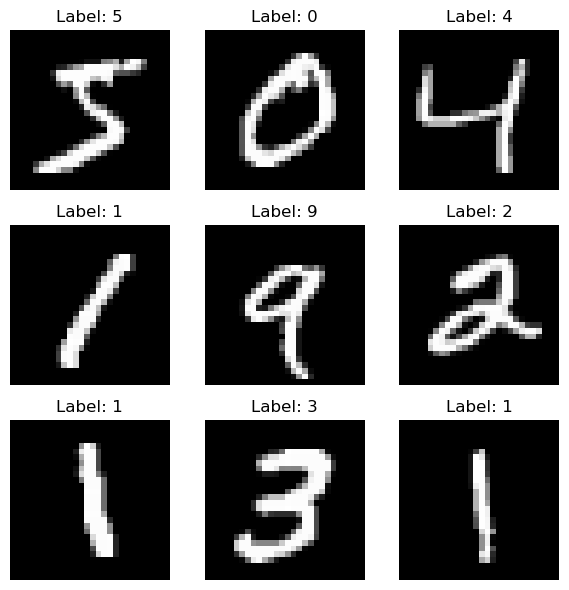

In [77]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X.iloc[i].values.reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


### Pixel Intensity Analysis

Pixel intensity analysis is the ***process of analyzing the brightness or intensity of pixels*** within an image to extract quantitative information. 

Pixel intensity: The brightness value of a single pixel. 

- In a grayscale image, a pixel's intensity is a single value, often ranging from 0 (black) to 255 (white)  
  or an 8-bit image. 
- In a color image, there are multiple intensity values (e.g., one for red, green, and blue). 

**Region of Interest (ROI)**: A specific area within an image that is selected for analysis. Analyzing the intensity of pixels only within the ROI can be more meaningful than analyzing the entire image. 

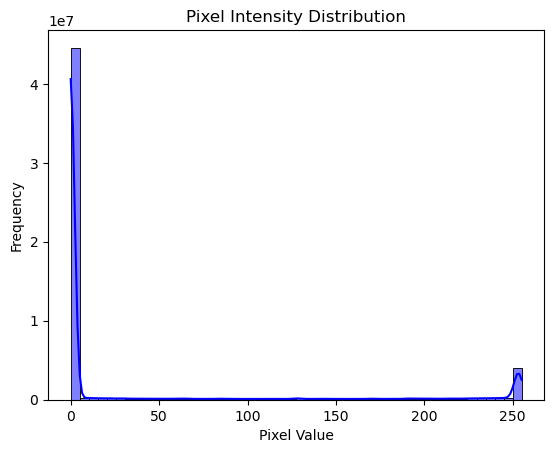

In [78]:
sns.histplot(X.values.flatten(), bins=50, kde=True, color='blue')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


**Interpretations**: Most pixel near 0 (background), will long tails towards 255(link)

### Brightness Level per Digit Class (MNIST_784)

To compute the average brightness level per digit class in the MNIST_784 dataset, you can calculate the mean pixel intensity for each image and then group by the digit label.

### What This Tells You

- Digits like 1 or 7 may have lower brightness (fewer strokes).
- Digits like 8 or 0 may have higher brightness (more filled pixels).
- Useful for feature engineering, normalization, or class-specific preprocessing


In [79]:
brightness = X.mean(axis=1)

# Combine with labels
df = pd.DataFrame({'label': y, 'brightness': brightness})

# Group by digit class and compute average brightness
avg_brightness = df.groupby('label')['brightness'].mean().sort_index()

print("Average brightness per digit class:\n")
print(avg_brightness)


Average brightness per digit class:

label
0    44.177405
1    19.406802
2    38.034208
3    36.154209
4    30.996000
5    32.950159
6    35.234865
7    29.217987
8    38.397901
9    31.359408
Name: brightness, dtype: float64


#### Heatmap of mean pixel intensity

To create a heatmap of mean pixel intensity for the MNIST_784 dataset:
- Compute the average pixel value across all images.
- Reshape the 784-dimensional vector into a 28×28 grid.
- Show which part of the image are most **active** across the dataset

#### How to Draw

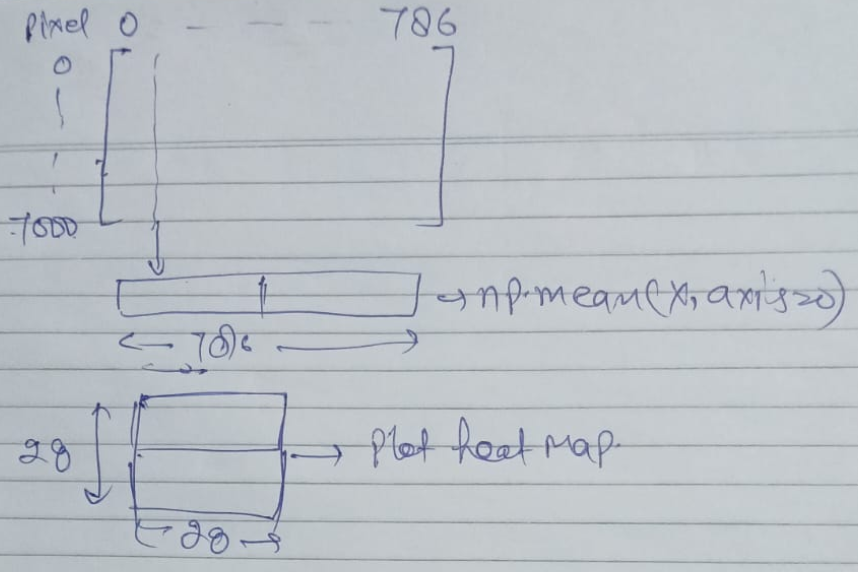


In [95]:
# To understand hot get mean and variance of Pixel(Baserd on above diagram)
# Define the 9x9 pixel intensity matrix
pixel_data = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 113, 113, 113, 113, 1, 0, 0],
    [0, 1, 113, 100, 120, 113, 1, 0, 0],
    [0, 1, 113, 255, 175, 113, 1, 0, 0],
    [0, 1, 113, 200, 210, 113, 1, 0, 0],
    [0, 1, 113, 113, 113, 113, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0]
]
# Create DataFrame
dfTest = pd.DataFrame(pixel_data)

# Optional: Label rows and columns
dfTest.index.name = 'Row'
dfTest.columns.name = 'Col'
#print(dfTest)
Mean_Pix = np.mean(dfTest.to_numpy(), axis=0)
print(f'Mean of pixel: {np.round(np.array(Mean_Pix),3)}')
Var_Pix = np.var(dfTest, axis=0)
print(f'Var of pixel: {np.round(np.array(Var_Pix),3)}')


Mean of pixel: [ 0.     0.778 63.    87.    81.444 63.     0.778  0.     0.   ]
Var of pixel: [0.000000e+00 1.730000e-01 3.125111e+03 8.049333e+03 6.107358e+03
 3.125111e+03 1.730000e-01 0.000000e+00 0.000000e+00]


Shape of Mean Pixel: (784,),Shape of Image: (70000, 784)


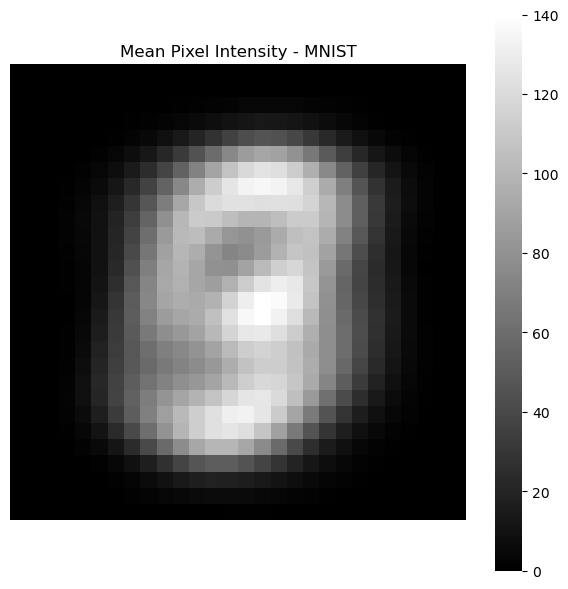

In [80]:

mean_pixels = np.mean(X, axis=0)
print(f'Shape of Mean Pixel: {mean_pixels.shape},Shape of Image: {X.shape}')

#Reshape to 28×28 grid
mean_image = mean_pixels.values.reshape(28, 28)
# Plot heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(mean_image, cmap='gray', cbar=True, square=True,
            xticklabels=False, yticklabels=False)

plt.title("Mean Pixel Intensity - MNIST")
plt.tight_layout()
plt.show()



## Correlation & Redundancy

#### what is redundant pixels

Redundant pixels are pixels in an image or video that contain information that is already present in neighboring pixels (spatial redundancy) or in previous frames (temporal redundancy).

***Useful for PCA or feature selection***

- Constant across all images (e.g., always zero)
- Highly correlated with other pixels
- Have very low variance

### Why Remove Redundant Pixels?

- Reduces dimensionality
- Speeds up training
- Improves generalization
- Helps visualization (e.g., PCA, t-SNE)


#### Pixels with Zero Variance




In [81]:
# Compute variance per pixel
pixel_variance = np.var(X, axis=0)

# Find pixels with zero or near-zero variance
redundant_pixels = np.where(pixel_variance < 1e-5)[0]

print(f"Number of redundant pixels (near-zero variance): {len(redundant_pixels)}")
print("Pixel indices:", redundant_pixels)


Number of redundant pixels (near-zero variance): 65
Pixel indices: [  0   1   2   3   4   5   6   7   8   9  10  11  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  52  53  54  55  56  57  82  83
  84  85 111 112 140 168 476 560 644 671 672 673 699 700 701 727 728 729
 730 754 755 756 757 758 759 780 781 782 783]


#### Pixels Always Zero

In [83]:
zero_pixels = np.where(np.all(X == 0, axis=0))[0]
print(f"Pixels always zero across all images: {zero_pixels}")

Pixels always zero across all images: [  0   1   2   3   4   5   6   7   8   9  10  11  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  52  53  54  55  56  57  82  83
  84  85 111 112 140 168 476 560 644 671 672 673 699 700 701 727 728 729
 730 754 755 756 757 758 759 780 781 782 783]


#### Highly Correlated Pixels


In [96]:
dfCorr = pd.DataFrame(X)

# Compute correlation matrix
corr_matrix = dfCorr.corr()

# Mask upper triangle and self-correlations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_matrix_masked = corr_matrix.mask(mask)

# Find pixel pairs with correlation > 0.95
high_corr_pairs = corr_matrix_masked.stack().reset_index()
high_corr_pairs.columns = ['Pixel 1', 'Pixel 2', 'Correlation']
redundant_corr = high_corr_pairs[high_corr_pairs['Correlation'] > 0.95]

print(f"Highly correlated pixel pairs:\n{redundant_corr}")

Highly correlated pixel pairs:
         Pixel 1   Pixel 2  Correlation
5        pixel16   pixel15     1.000000
1152     pixel87   pixel59     0.955718
16625   pixel225  pixel197     0.963590
28413   pixel281  pixel253     0.956088
71603   pixel421  pixel393     0.982570
163850  pixel617  pixel589     1.000000
179672  pixel644  pixel616     1.000000
179800  pixel646  pixel142     1.000000
228125  pixel727  pixel699     0.983547


### Outlier Detection (Optional)

### Normalization


